In [88]:
import webdataset as wds
import numpy as np
from PIL import Image
import io

train_bg_path = "/shared/anastasio-s2/SOM/kaiyan/mri_1000_200k/background_train.npy"
test_bg_path = "/shared/anastasio-s2/SOM/kaiyan/mri_1000_200k/background_test.npy"

bg_array = np.load(train_bg_path, mmap_mode='r')
bg_test_array = np.load(test_bg_path, mmap_mode='r')

bg_array = bg_array[:, :, :, 0]
bg_val_array = bg_test_array[:5000, :, :, 0]
bg_test_array = bg_test_array[5000:, :, :, 0]

In [89]:
bg_array.shape

(171592, 260, 311)

In [215]:
import os
# 1. Define where to save the shards and the naming pattern (e.g., dataset-000000.tar)
save_path = '/shared/anastasio-s2/SI/HCP_selected/background/train/'

os.makedirs(save_path, exist_ok=True)

pattern = os.path.join(save_path, "dataset-%06d.tar")

# 2. Maximum number of items per shard (1000 is a good default)
maxcount = 10000
maxsize = 1e10

# 3. Create the ShardWriter
with wds.ShardWriter(pattern, maxcount=maxcount, maxsize=maxsize) as sink:

    # Iterate through your 300,000 images.
    # (Replace this loop with however you currently access your raw data)
    for i in range(bg_array.shape[0]):
        # Fetch your image and label (Example placeholders)
        image_array = bg_array[i, :, :] #  (your 280x320 array)
        # label = ... (your integer label)

        npy_byte_arr = io.BytesIO()
        np.save(npy_byte_arr, image_array)
        npy_bytes = npy_byte_arr.getvalue()

        # 2. Update your sample dictionary to use the "npy" extension
        sample = {
            "__key__": f"sample_{i:06d}",
            "npy": npy_bytes,  # Notice we use 'npy' instead of 'jpg'
        }

        # 5. Write the sample to the current shard
        sink.write(sample)

print("Finished writing all shards!")

# writing /shared/anastasio-s2/SI/HCP_selected/background/train/dataset-000000.tar 0 0.0 GB 0
# writing /shared/anastasio-s2/SI/HCP_selected/background/train/dataset-000001.tar 10000 3.2 GB 10000
# writing /shared/anastasio-s2/SI/HCP_selected/background/train/dataset-000002.tar 10000 3.2 GB 20000
# writing /shared/anastasio-s2/SI/HCP_selected/background/train/dataset-000003.tar 10000 3.2 GB 30000
# writing /shared/anastasio-s2/SI/HCP_selected/background/train/dataset-000004.tar 10000 3.2 GB 40000
# writing /shared/anastasio-s2/SI/HCP_selected/background/train/dataset-000005.tar 10000 3.2 GB 50000
# writing /shared/anastasio-s2/SI/HCP_selected/background/train/dataset-000006.tar 10000 3.2 GB 60000
# writing /shared/anastasio-s2/SI/HCP_selected/background/train/dataset-000007.tar 10000 3.2 GB 70000
# writing /shared/anastasio-s2/SI/HCP_selected/background/train/dataset-000008.tar 10000 3.2 GB 80000
# writing /shared/anastasio-s2/SI/HCP_selected/background/train/dataset-000009.tar 10000 3

In [77]:
# import os
# # 1. Define where to save the shards and the naming pattern (e.g., dataset-000000.tar)
# save_path = '/shared/anastasio-s2/SI/HCP_selected/background/test/'
#
# os.makedirs(save_path, exist_ok=True)
#
# pattern = os.path.join(save_path, "dataset-%06d.tar")
#
# # 2. Maximum number of items per shard (1000 is a good default)
# maxcount = 1000
#
# # 3. Create the ShardWriter
# with wds.ShardWriter(pattern, maxcount=maxcount) as sink:
#
#     # Iterate through your 300,000 images.
#     # (Replace this loop with however you currently access your raw data)
#     for i in range(bg_test_array.shape[0]):
#         # Fetch your image and label (Example placeholders)
#         image_array = bg_test_array[i, :, :] #  (your 280x320 array)
#         # label = ... (your integer label)
#
#         npy_byte_arr = io.BytesIO()
#         np.save(npy_byte_arr, image_array)
#         npy_bytes = npy_byte_arr.getvalue()
#
#         # 2. Update your sample dictionary to use the "npy" extension
#         sample = {
#             "__key__": f"sample_{i:06d}",
#             "npy": npy_bytes,  # Notice we use 'npy' instead of 'jpg'
#         }
#
#         # 5. Write the sample to the current shard
#         sink.write(sample)
#
# print("Finished writing all shards!")

# writing /shared/anastasio-s2/SI/HCP_selected/background/test/dataset-000000.tar 0 0.0 GB 0
# writing /shared/anastasio-s2/SI/HCP_selected/background/test/dataset-000001.tar 1000 0.3 GB 1000
# writing /shared/anastasio-s2/SI/HCP_selected/background/test/dataset-000002.tar 1000 0.3 GB 2000
# writing /shared/anastasio-s2/SI/HCP_selected/background/test/dataset-000003.tar 1000 0.3 GB 3000
# writing /shared/anastasio-s2/SI/HCP_selected/background/test/dataset-000004.tar 1000 0.3 GB 4000
Finished writing all shards!


In [95]:
from torchvision import transforms
from torch.utils.data import DataLoader

# url = "/shared/anastasio-s2/SI/HCP_selected/background/train/dataset-{000000..000299}.tar"
url = "/shared/anastasio-s2/SI/HCP_selected/background/train/dataset-000000.tar"

# 3. Build the dataset pipeline
dataset = (
    wds.WebDataset(url)
    .shuffle(10000)               # Shuffle the shards and maintain a local buffer of 1000 samples
    .decode("torch")
    .to_tuple("npy")              # Extract the "jpg" and "cls" keys we defined during writing
    .batched(256)                 # Batch them together (e.g., batch size 64)
)

# 4. Pass the WebDataset to the standard PyTorch DataLoader
# Note: batch_size=None because WebDataset already handled the batching above!
dataloader = DataLoader(dataset, num_workers=1, batch_size=None)

In [208]:
iters = iter(dataloader)
d = next(iters)

images = d[0]

In [209]:
import torch

sigma = 3.0
amplitude = 0.2

x0, y0 = 170, 220

H, W = 260, 311
target_size = 272, 320

X, Y = torch.meshgrid(
torch.arange(H, device='cuda'),
torch.arange(W, device='cuda'),
indexing='ij'
)
distance_sq = (X - x0) ** 2 + (Y - y0) ** 2
within_3sigma = distance_sq <= (3 * sigma) ** 2

signal = torch.zeros((H, W), dtype=torch.float32, device='cuda')
signal[within_3sigma] = amplitude * torch.exp(-0.5 * distance_sq[within_3sigma] / (sigma ** 2))

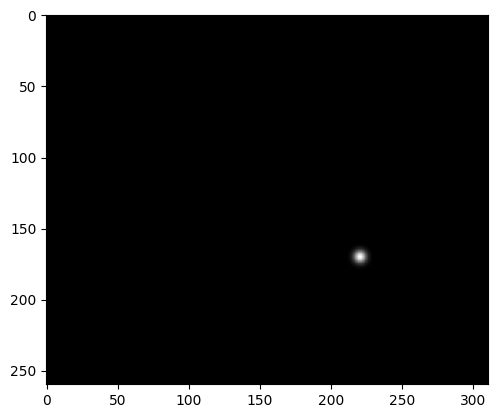

In [210]:
import matplotlib.pyplot as plt

plt.imshow(signal.detach().cpu(), cmap='gray')

In [211]:
def apply_kspace_noise(imgs, mask, noise_level):
    """
    Applies complex noise in the k-space (frequency domain) to a batch of images.
    Expects imgs shape: (B, H, W) or (B, C, H, W)
    """
    # Perform batched 2D FFT
    kspace = torch.fft.fft2(imgs)

    # Generate batched complex noise
    noise_real = torch.randn_like(imgs) * noise_level
    noise_imag = torch.randn_like(imgs) * noise_level
    noise = torch.complex(noise_real, noise_imag)

    # Add noise and apply mask
    kspace_noisy = (kspace + noise)

    # Perform batched 2D Inverse FFT and take the absolute value (magnitude image)
    img_recon = torch.fft.ifft2(kspace_noisy)
    return torch.real(img_recon)

In [212]:
images = images.to('cuda')
import torch.nn.functional as F
noise_level = 35.0

B, H, W = images.shape
half_B = B // 2

mask = np.ones((H, W), dtype=np.float32)

# ---------------------------------------------------------
# STEP A: Create and Add Signal to the FIRST HALF
# (Do this before padding so your y0, x0 coordinates stay accurate to the anatomy!)
# ---------------------------------------------------------

# Inject the localized signal into the first half of the batch
images[:half_B] = images[:half_B] + signal

target_H, target_W = target_size
pad_h = target_H - H
pad_w = target_W - W

pad_tuple = (
    max(0, pad_w // 2),
    max(0, pad_w - pad_w // 2),
    max(0, pad_h // 2),
    max(0, pad_h - pad_h // 2)
)
# The empty padded areas are currently 0.0
images = F.pad(images, pad_tuple, mode="constant", value=0.0)

feats = apply_kspace_noise(images, mask, noise_level)
task_label = torch.zeros(B, dtype=torch.long, device='cuda')
task_label[:half_B] = 1

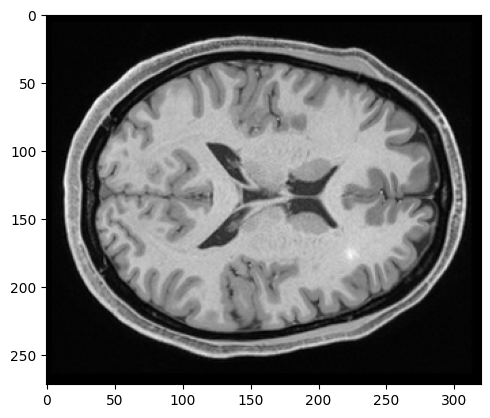

In [213]:
plt.imshow(images[110].detach().cpu(), cmap='gray')

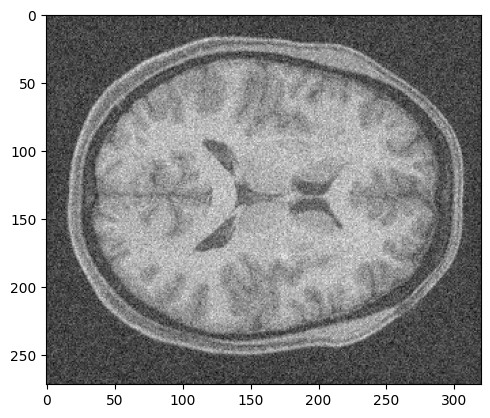

In [139]:
plt.imshow(feats[0].detach().cpu(), cmap='gray')

In [223]:
n_data = 2
end_index = n_data - 1

if n_data == 1:
    # For a single file, we don't need the brace expansion
    train_image_path = '/shared/anastasio-s2/SI/HCP_selected/background/train/dataset-000000.tar'
else:
    # For multiple files, we use an f-string to inject the end_index.
    # Note: We use double curly braces {{ and }} to output literal curly braces
    # in the final string, and {end_index:06d} to format the number with leading zeros.
    train_image_path = f'/shared/anastasio-s2/SI/HCP_selected/background/train/dataset-{{000000..{end_index:06d}}}.tar'

In [224]:
print(train_image_path)

/shared/anastasio-s2/SI/HCP_selected/background/train/dataset-{000000..000001}.tar


In [ ]:
if n_data < 4:
    args.num_workers = n_data